In [1]:
import sys
import csv
import os
import json
import torch
import pandas as pd
from dotenv import load_dotenv, find_dotenv

# Load .env
load_dotenv(find_dotenv())

# -------------------------
# Config
# -------------------------
SEED = int(os.environ.get("SEED", 42))
DATA_DIR = os.environ.get("DATA_DIR", "/workspace/data")

raw_data_dir = os.path.join(DATA_DIR, "raw_pubmed_data")
parsed_docs_dir = os.path.join(DATA_DIR, "parsed_docs")
train_csv_path = os.path.join(parsed_docs_dir, "training_final.csv")
test_csv_path = os.path.join(parsed_docs_dir, "test_final.csv")

# -------------------------
# Environment Info
# -------------------------
print(f"SEED: {SEED}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"PyTorch version: {torch.__version__}")
print(f"Data dir: {DATA_DIR}")
print(f"Train CSV path: {train_csv_path}")
print(f"Test CSV path: {test_csv_path}")

SEED: 42
CUDA available: True
PyTorch version: 2.2.0
Data dir: /workspace/data
Train CSV path: /workspace/data/parsed_docs/training_final.csv
Test CSV path: /workspace/data/parsed_docs/test_final.csv


## Section Distribution in BioASQ Golden Snippets

In [2]:
DATASET_REGISTRY = {}

# Only load these datasets
ALLOWED_DATASETS = {'13B1_golden', '13B2_golden', '13B3_golden', '13B4_golden', 'training13b'}

print('📂 Loading standard JSON files...')
if not os.path.isdir(raw_data_dir):
    print(f'❌ Directory not found: {raw_data_dir}')
else:
    for filename in sorted(os.listdir(raw_data_dir)):
        if filename.endswith('.json'):
            dataset_name = os.path.splitext(filename)[0]

            if dataset_name not in ALLOWED_DATASETS:  # ← filter here
                print(f'⏭️  Skipping: {filename}')
                continue

            file_path = os.path.join(raw_data_dir, filename)
            with open(file_path, 'r', encoding='utf-8') as f:
                try:
                    raw_data = json.load(f)
                    if isinstance(raw_data, dict) and 'questions' in raw_data:
                        data_list = raw_data['questions']
                    elif isinstance(raw_data, list):
                        data_list = raw_data
                    else:
                        data_list = [raw_data]
                    DATASET_REGISTRY[dataset_name] = {'data': data_list}
                except json.JSONDecodeError as e:
                    print(f'⚠️ Could not parse {filename}: {e}')

print('\n📋 Dataset Inventory:')
for name, meta in DATASET_REGISTRY.items():
    print(f'  [{name}] — {len(meta["data"])} documents')

📂 Loading standard JSON files...

📋 Dataset Inventory:
  [13B1_golden] — 85 documents
  [13B2_golden] — 85 documents
  [13B3_golden] — 85 documents
  [13B4_golden] — 85 documents
  [training13b] — 5389 documents


In [3]:
questions = raw_data["questions"]

records = []

for q in questions:
    for s in q.get("snippets", []):
        records.append({
            "beginSection": s.get("beginSection"),
            "endSection": s.get("endSection")
        })

df_sections = pd.DataFrame(records)

# ----------------------------------
# Count section frequencies
# ----------------------------------

begin_counts = df_sections["beginSection"].value_counts()
end_counts = df_sections["endSection"].value_counts()

print("\nbeginSection counts:")
print(begin_counts)

print("\nendSection counts:")
print(end_counts)


beginSection counts:
beginSection
abstract      57162
title          7623
sections.0     4075
Name: count, dtype: int64

endSection counts:
endSection
abstract      57162
title          7623
sections.0     4075
Name: count, dtype: int64


## Load the CSV and parse the abstracts column

In [4]:
# Read only first 10 rows
df_train_raw = pd.read_csv(train_csv_path, engine="python")
df_train = df_train_raw.copy()

## Basic Dataset Overview

In [5]:
print("Rows:", len(df_train))
print("Columns:", df_train.columns.tolist())

df_train.info()

Rows: 39418
Columns: ['question', 'type', 'text', 'category', 'topic_id', 'confidence', 'pmid', 'source_url', 'n_sources']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39418 entries, 0 to 39417
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   question    39418 non-null  object 
 1   type        39418 non-null  object 
 2   text        39417 non-null  object 
 3   category    39418 non-null  object 
 4   topic_id    39418 non-null  int64  
 5   confidence  39418 non-null  float64
 6   pmid        39418 non-null  int64  
 7   source_url  39418 non-null  object 
 8   n_sources   39418 non-null  int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 2.7+ MB


In [6]:
df_train.isnull().sum()

question      0
type          0
text          1
category      0
topic_id      0
confidence    0
pmid          0
source_url    0
n_sources     0
dtype: int64

## Unique Questions

In [7]:
df_train["question"].value_counts()

question
Which is the causative agent of malaria?                                                                                                    105
In which proteins is the chromodomain present?                                                                                              102
What tyrosine kinase, involved in a Philadelphia- chromosome positive chronic myelogenous leukemia, is the target of Imatinib (Gleevec)?     79
Is miR-21 related to carcinogenesis?                                                                                                         69
What clinical conditions influence the prognostic after the liver metastasis resection from colorectal cancer patients?                      65
                                                                                                                                           ... 
What methodology does the HercepTest use?                                                                                      

## Category Distribution

In [8]:
df_train["category"].value_counts()

category
Other                    5690
Pharmacology & Drugs     5511
Molecular Biology        4503
Rare Diseases            3909
Cancer & Oncology        3587
Genetics & Mutations     3536
Infectious Disease       3145
Immunology               3036
Cardiology & Heart       2150
Surgery & Procedures     1632
Neurology & Brain        1345
Mental Health             445
Diagnostics & Imaging     393
Metabolism & Diabetes     353
Clinical Guidelines       183
Name: count, dtype: int64

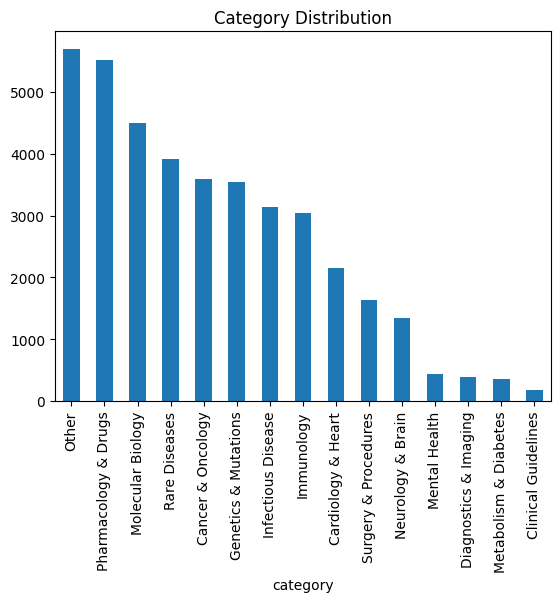

In [9]:
import matplotlib.pyplot as plt

df_train["category"].value_counts().plot(kind="bar")
plt.title("Category Distribution")
plt.show()

## Question Type Distribution

In [10]:
df_train["type"].value_counts()

type
factoid    11797
yesno      10856
list        9025
summary     7740
Name: count, dtype: int64

## Text Length Analysis (VERY IMPORTANT for chunking)

### Character length

In [11]:
df_train["text_len"] = df_train["text"].str.len()

df_train["text_len"].describe()

count    39417.000000
mean      1708.009767
std        996.902810
min         61.000000
25%       1302.000000
50%       1648.000000
75%       1970.000000
max      35283.000000
Name: text_len, dtype: float64

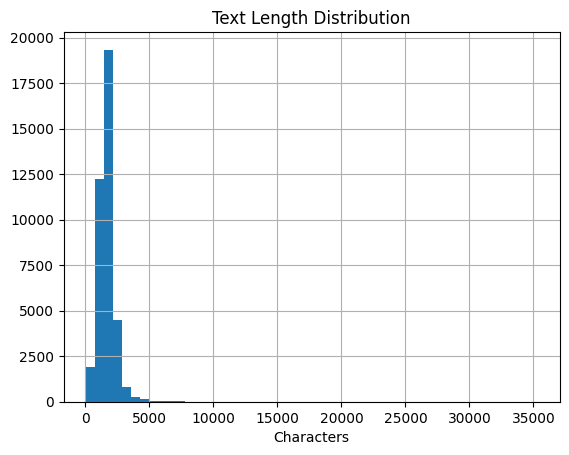

In [12]:
df_train["text_len"].hist(bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Characters")
plt.show()

### Word length

In [13]:
df_train["text"] = df_train["text"].fillna("")

df_train["word_len"] = df_train["text"].str.split().apply(len)

df_train["word_len"].describe()

count    39418.000000
mean       243.820666
std        142.418445
min          0.000000
25%        186.000000
50%        236.000000
75%        281.000000
max       5109.000000
Name: word_len, dtype: float64

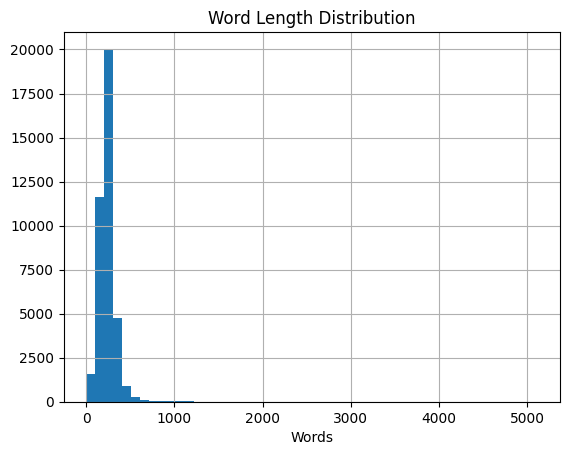

In [14]:
df_train["word_len"].hist(bins=50)
plt.title("Word Length Distribution")
plt.xlabel("Words")
plt.show()

## Inspect Text Quality

In [15]:
for i in range(5):
    print(df_train["text"].iloc[i])
    print("-"*80)

risk. Emison ES(1), McCallion AS, Kashuk CS, Bush RT, Grice E, Lin S, Portnoy ME, Cutler DJ, Green ED, Chakravarti A. Author information: The identification of common variants that contribute to the genesis of human inherited disorders remains a significant challenge. Hirschsprung disease (HSCR) is a multifactorial, non-mendelian disorder in which rare high-penetrance coding sequence mutations in the receptor tyrosine kinase RET contribute to risk in combination with mutations at other genes. We have used family-based association studies to identify a disease interval, and integrated this with comparative and functional genomic analysis to prioritize conserved and functional elements within which mutations can be sought. We now show that a common non-coding RET variant within a conserved enhancer-like sequence in intron 1 is significantly associated with HSCR susceptibility and makes a 20-fold greater contribution to risk than rare alleles do. This mutation reduces in vitro enhancer ac

## Token Length Estimation (for embeddings)

In [16]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2")

df_train["tokens"] = df_train["text"].apply(lambda x: len(tokenizer.encode(x)))

df_train["tokens"].describe()

/opt/conda/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
Token indices sequence length is longer than the specified maximum sequence length for this model (599 > 512). Running this sequence through the model will result in indexing errors


count    39418.000000
mean       416.839211
std        270.069032
min          2.000000
25%        305.000000
50%        392.000000
75%        483.000000
max       9328.000000
Name: tokens, dtype: float64

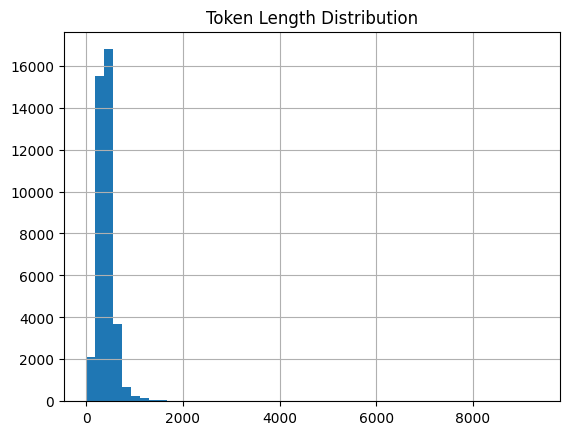

In [17]:
df_train["tokens"].hist(bins=50)
plt.title("Token Length Distribution")
plt.show()

## Best Strategy for Your Dataset

### Only chunk the outliers

In [18]:
df_train["needs_chunking"] = df_train["tokens"] > 800
df_train["needs_chunking"].value_counts()

needs_chunking
False    38401
True      1017
Name: count, dtype: int64